# Midterm Exam (part 2) - Computational Physics I

### Deadline: Monday 13 October 2025 (by 19h00)
### Name: Mejia Perez Bady Fernando

## Part 2. (10 points) Data fitting and regression: absorption spectral lines


#### Spectrum data file:

https://github.com/wbandabarragan/physics-teaching-data/blob/main/1D-data/j124257-7533_spectra.txt

#### File description:

The supplied data file contains observational data from the ATCA radio telescope (ATCA stands for Australia Telescope Compact Array (see https://en.wikipedia.org/wiki/Australia_Telescope_Compact_Array). The data corresponds to HI clouds in the Chamaeleon molecular cloud complex (see https://en.wikipedia.org/wiki/Chamaeleon_complex).

This data file contains absorption line features from neutral hydrogen (HI, i.e., $\lambda = 21\,\rm cm$) in the Milky Way, and continuum emission from a distant quasar that is used as "background light" for observing the HI in the Milky Way (see the Figure below). We can assume that each gas cloud in our line of sight towards the background source produces a Gaussian absorption feature that is only dependent on the opical depth, $\tau$, of the gas cloud. The higher the optical depth, the deeper the absorption feature. 

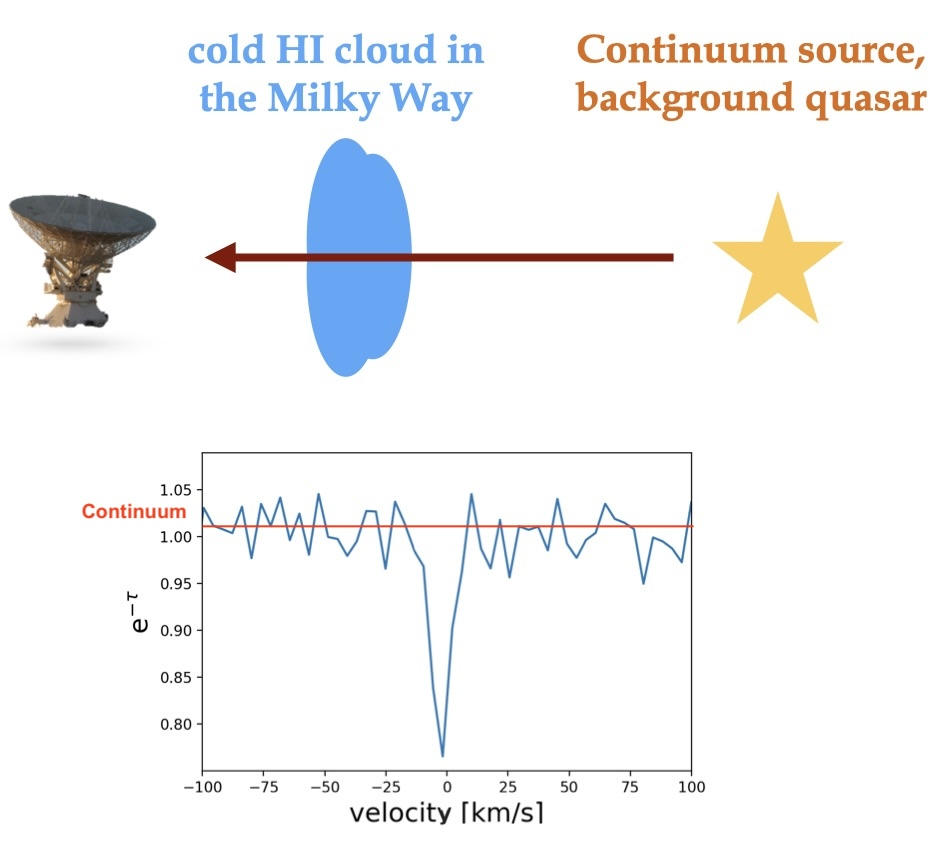

### Part A: Data I/O and inspection

Within a single python notebook, carry out the following tasks:

(a) Create an I/O function that reads in the spectral data from the file and returns velocity and intensity as arrays.

In [179]:
#Libraries for use in all file 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

In [180]:
def read_file(name):
    data=pd.read_csv(name,sep=' ')# the library pandas can read .txt from repository in github with raw direction
    data=pd.DataFrame(data)
    print(data)
    vel=np.array(data['velocity'])
    I=np.array(data['intensity'])
    return vel,I,data ## return two numpy array and a dataframe 


(b) Call your I/O and make a plot of the spectrum (velocity on the x-axis and intensity on the y-axis). How many "HI clouds" do you see? Note that each Gaussian-like feature represents a separate HI cloud.

In [181]:
url_data='https://raw.githubusercontent.com/wbandabarragan/physics-teaching-data/refs/heads/main/1D-data/j124257-7533_spectra.txt'
velocity,intensity,data_frame=read_file(url_data)

       velocity  intensity
0   -100.000000   0.535824
1    -99.800000   0.480186
2    -99.600000   0.511209
3    -99.400000   0.473837
4    -99.200000   0.479554
..          ...        ...
995   99.000004   0.512582
996   99.200004   0.498250
997   99.400004   0.487952
998   99.600004   0.415036
999   99.800004   0.460614

[1000 rows x 2 columns]


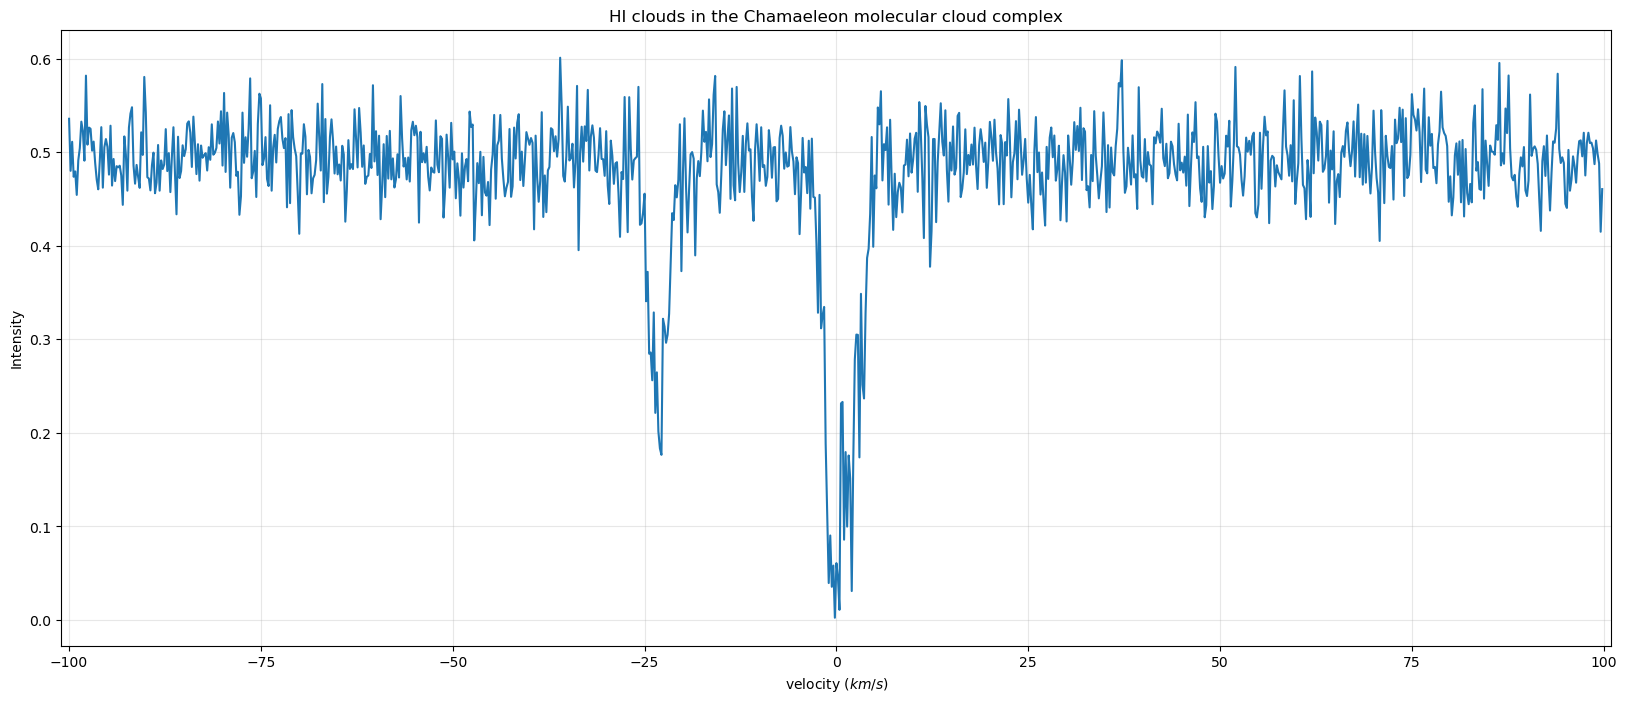

In [182]:
plt.figure(figsize=(20,8))
plt.plot(velocity,intensity)
plt.xlabel('velocity ($km/s$)')
plt.ylabel('Intensity')
plt.grid(True,alpha=0.3)
plt.xlim(-101,101)
plt.title('HI clouds in the Chamaeleon molecular cloud complex')
plt.show()

### According to the graph presented here, I can see a total of two HI clouds at points -25 and around 0, which are characteristic of absorption. 

### Part B: Continuum identification and removal

(c) Identify the background continuum emission by fitting a linear regression to the spectrum. This should be a horizontal line (i.e. with no slope) since the continuum emission is roughly constant. **Hint:** Do not include the absorption features in this regression (you can mask them out before carrying out the regression).

In [183]:
## for regretion we are going to use a filter for only take the intensity greater than 0.4 
def liner(x,a,b):
    return a*x+b
data_filter=data_frame[data_frame['intensity']>0.42]
values,error=opt.curve_fit(liner,data_filter['velocity'],data_filter['intensity'])
y_linear_continuum=liner(velocity,values[0],values[1])

In [184]:
## error for the values 
uncertainties=np.sqrt(np.diag(error))
print(f'pending = {values[0]:.2e} +/- {uncertainties[0]:.2e} \n b={values[1]:.2e} +/- {uncertainties[1]:.2e}')


pending = -8.71e-06 +/- 1.81e-05 
 b=4.95e-01 +/- 1.08e-03


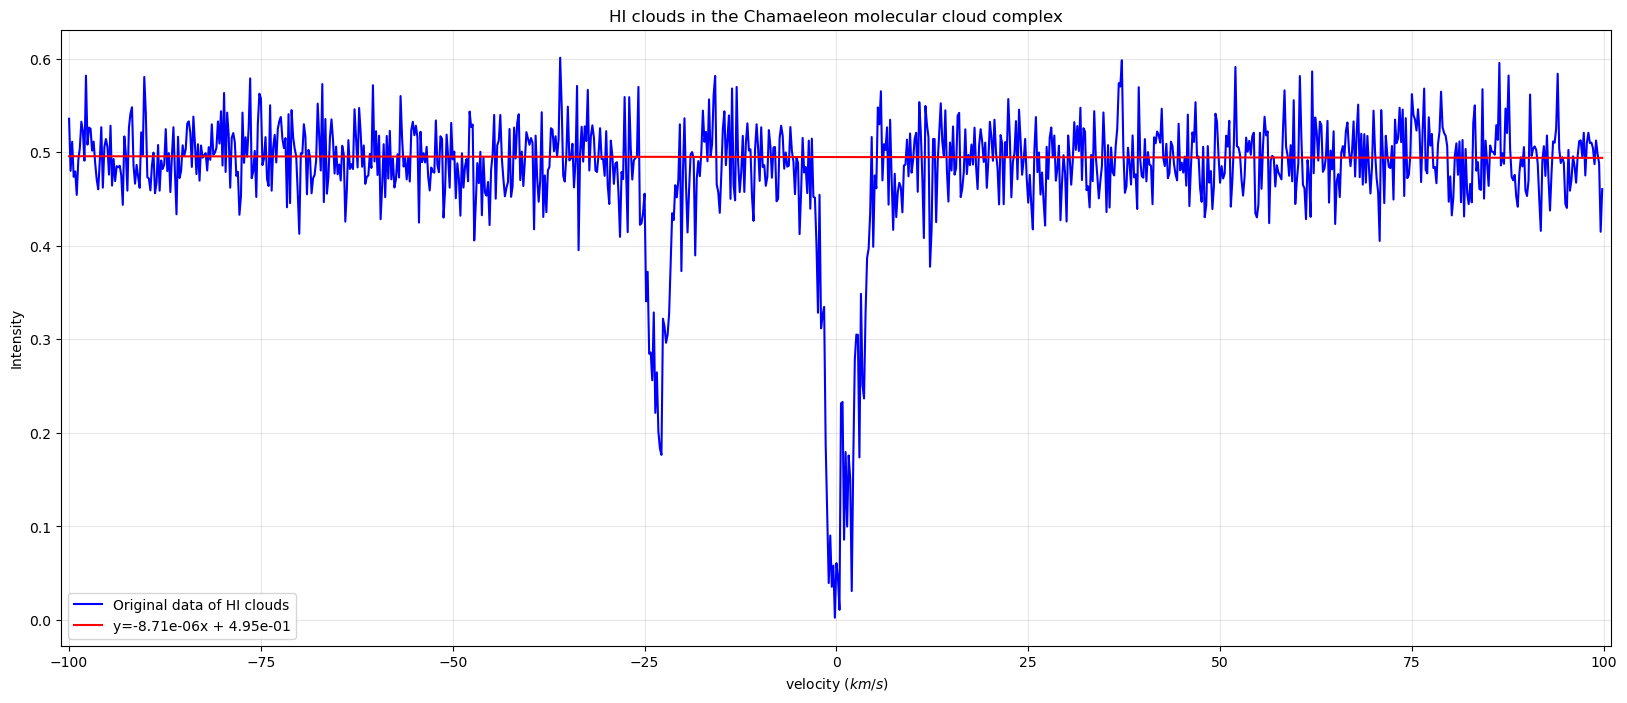

In [185]:
plt.figure(figsize=(20,8))
plt.plot(velocity,intensity,color='blue',label='Original data of HI clouds')
plt.plot(velocity,y_linear_continuum,color='red',label=f'y={values[0]:.2e}x + {values[1]:.2e}')
plt.title('HI clouds in the Chamaeleon molecular cloud complex')
plt.xlabel('velocity ($km/s$)')
plt.ylabel('Intensity')
plt.grid(True,alpha=0.3)
plt.xlim(-101,101)
plt.legend()
plt.show()

### The straight line drawn to describe the background continuum has a slope with a very small value, very close to zero, due to the interpolation method used. 

(d) Divide the whole spectrum by the fitted continuum emission from (d), and make a plot of it. The base of the spectrum should lie at $\sim +1$ on the y-axis. This step is neccesary to separate the HI absorption associated with the clouds from the background source.

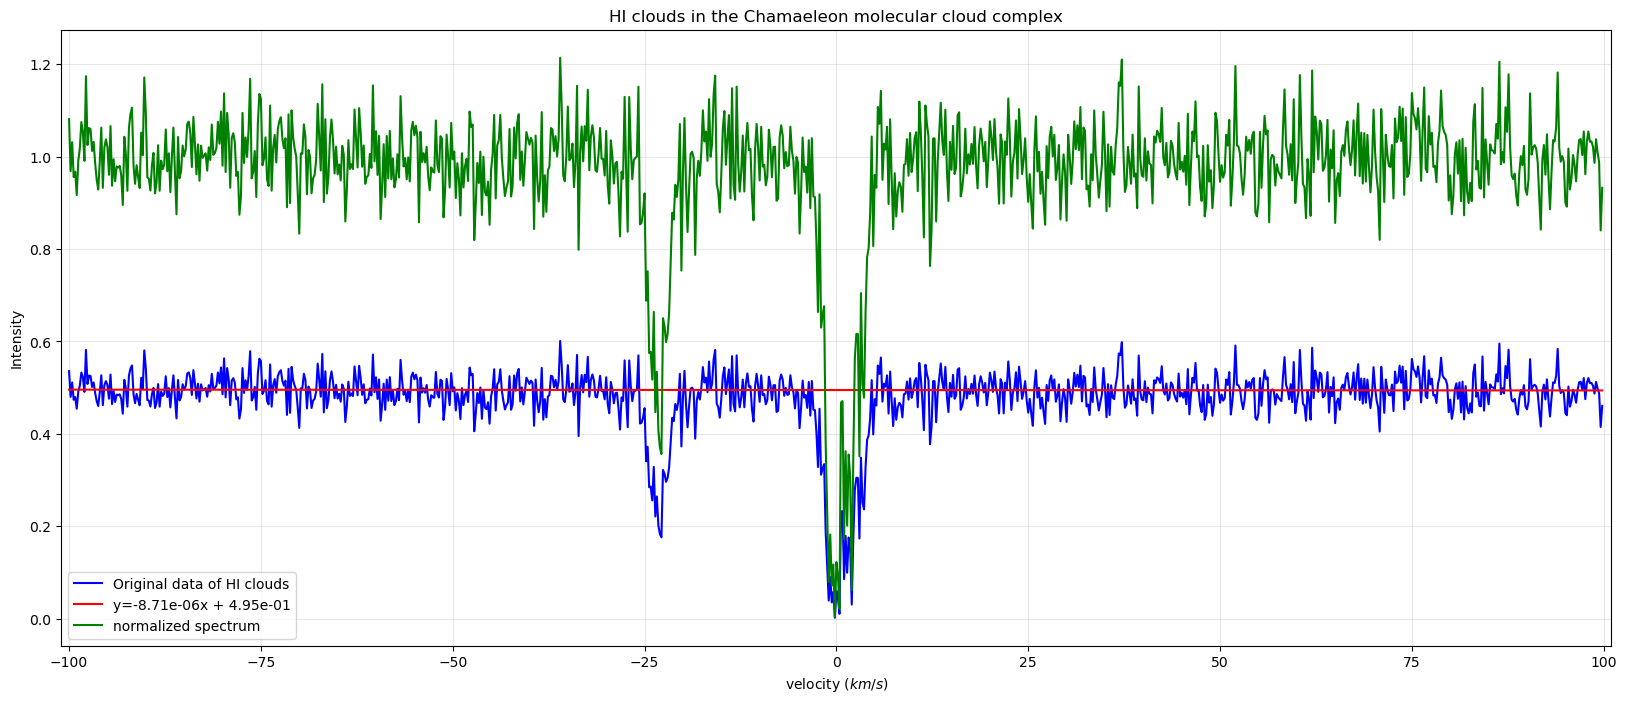

In [186]:
product_divided=intensity/y_linear_continuum

plt.figure(figsize=(20,8))
plt.plot(velocity,intensity,color='blue',label='Original data of HI clouds')
plt.plot(velocity,y_linear_continuum,color='red',label=f'y={values[0]:.2e}x + {values[1]:.2e}')
plt.plot(velocity,product_divided,color="green",label="normalized spectrum")
plt.title('HI clouds in the Chamaeleon molecular cloud complex')
plt.xlabel('velocity ($km/s$)')
plt.ylabel('Intensity')
plt.grid(True,alpha=0.3)
plt.xlim(-101,101)
plt.legend()
plt.show()

### Part D: Optical Depth Calculation

(e) Each point along the resulting spectrum obtained in (d) represents a specific optical depth value of the absorbing gas, namely each value of intensity is equal to $e^{-\tau}$, where $\tau$ is the optical depth of the HI gas. Thus, calculate the optical depth for each point and make a plot of optical depth versus velocity.

equation for calculate it we are going to use this equation 
$\tau$=- Ln($I_{nor}$)

In [187]:
tao=-np.log(product_divided)

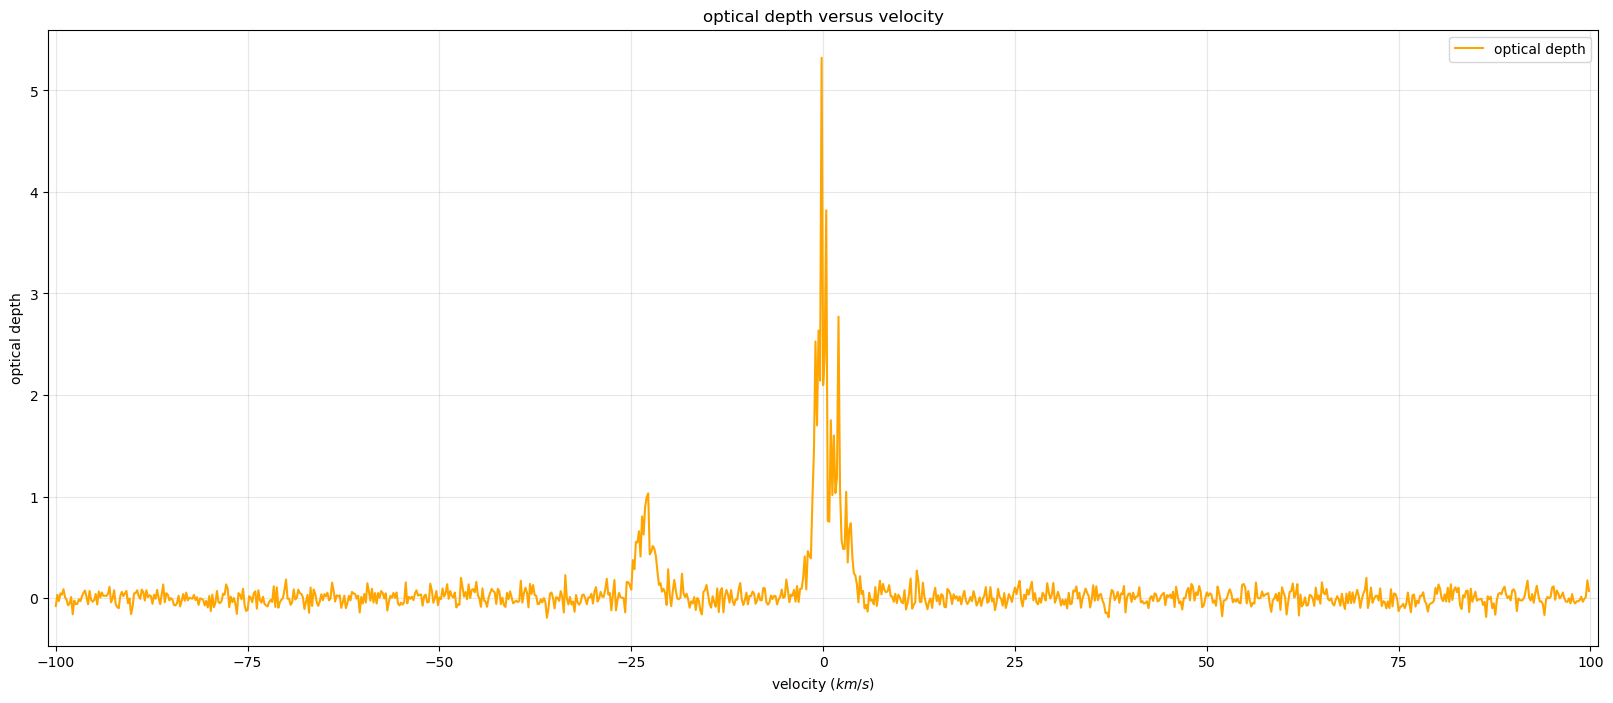

In [188]:
plt.figure(figsize=(20,8))
plt.plot(velocity,tao,color='orange',label='optical depth')
plt.title('optical depth versus velocity')
plt.xlabel('velocity ($km/s$)')
plt.ylabel('optical depth')
plt.grid(True,alpha=0.3)
plt.xlim(-101,101)
plt.legend()
plt.show()

#### (f) What is the maximum optical depth of the gas clouds that are represented in this spectra?

In [189]:
# using the dataframe for  search the max points of each gas cloud
gas_cloud=pd.DataFrame({'velocity':velocity,'optical depth':tao})
points_max=[]



In [190]:
def search_max(data,inicio,fin):
    tem=data[(data['velocity']>inicio) & (data['velocity']<fin)]
    local_max=np.max(tem['optical depth'])
    x_val=(tem[tem['optical depth']==local_max]).iloc[0,0]
    return [x_val,local_max]

 major points that we can see at a glance

In [191]:
points_max.append(search_max(gas_cloud,-26,-10))
points_max.append(search_max(gas_cloud,-10,10))
#points_max.append(search_max(gas_cloud,-26,-10))

By analyzing locally the points close to zero, we can find two local maximum points in the ranges [0,1] and [1,3].

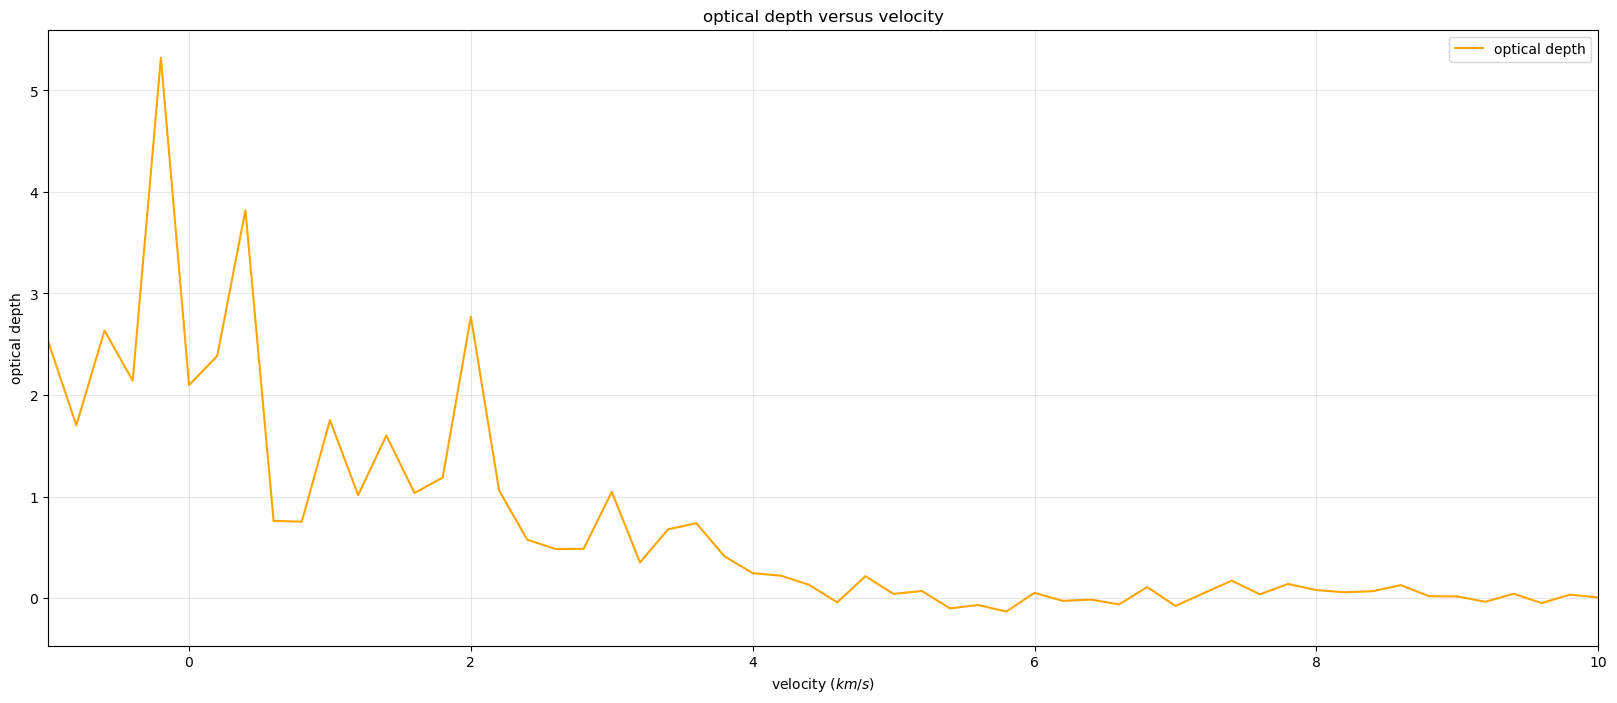

In [192]:
plt.figure(figsize=(20,8))
plt.plot(velocity,tao,color='orange',label='optical depth')
plt.title('optical depth versus velocity')
plt.xlabel('velocity ($km/s$)')
plt.ylabel('optical depth')
plt.grid(True,alpha=0.3)
plt.xlim(-1,10)
plt.legend()
plt.show()

In [193]:
points_max.append(search_max(gas_cloud,0,1))
points_max.append(search_max(gas_cloud,1,3))

In [194]:
points_max=np.array(points_max,dtype=float)
points_max

array([[-22.79999869,   1.03106001],
       [ -0.19999828,   5.32248563],
       [  0.40000173,   3.819874  ],
       [  2.00000176,   2.77198033]])

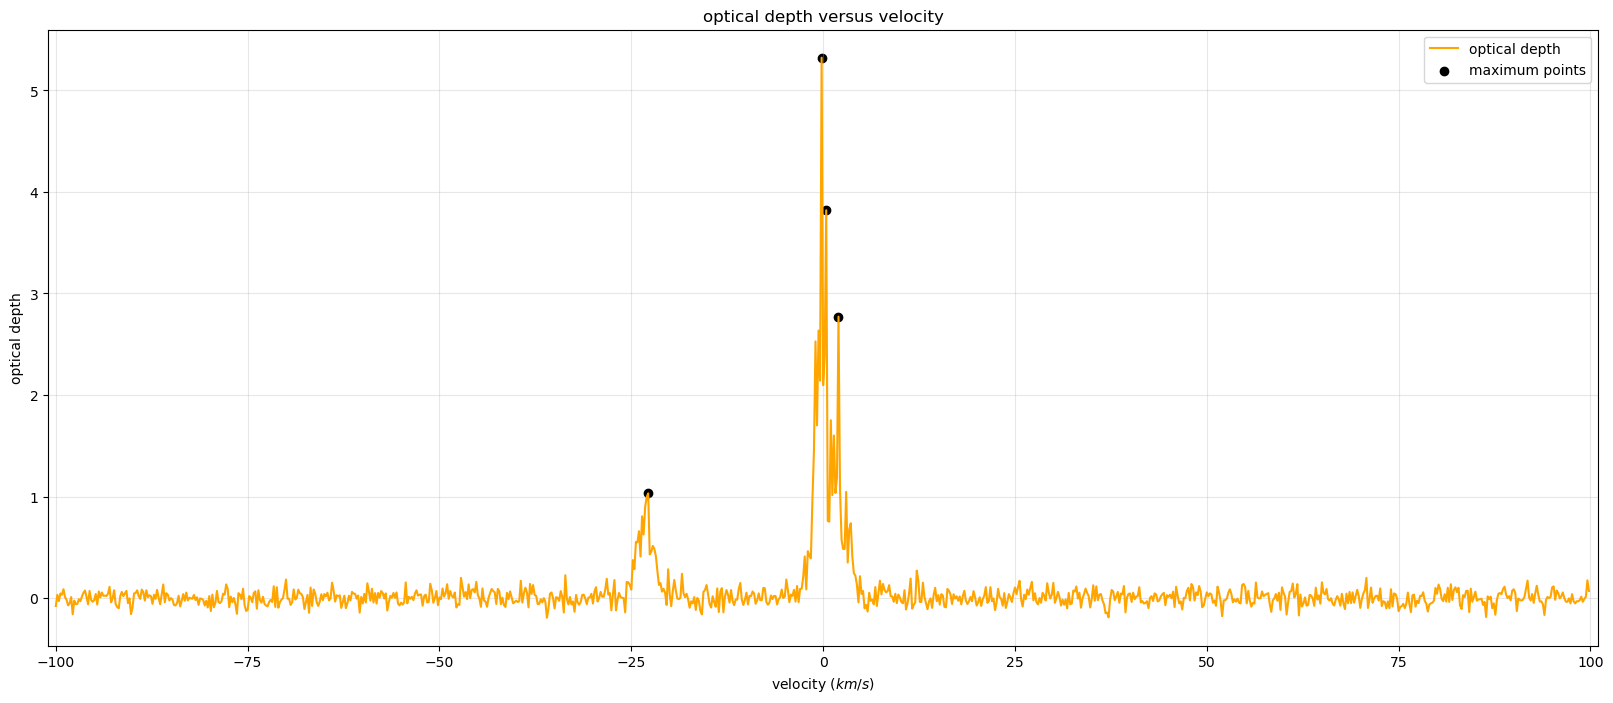

In [195]:
plt.figure(figsize=(20,8))
plt.plot(velocity,tao,color='orange',label='optical depth')
plt.scatter(points_max[:,0],points_max[:,1],color='black',label='maximum points')
plt.title('optical depth versus velocity')
plt.xlabel('velocity ($km/s$)')
plt.ylabel('optical depth')
plt.grid(True,alpha=0.3)
plt.xlim(-101,101)
plt.legend()
plt.show()

of the highest points of the spectrum

In [196]:
points_max

array([[-22.79999869,   1.03106001],
       [ -0.19999828,   5.32248563],
       [  0.40000173,   3.819874  ],
       [  2.00000176,   2.77198033]])

The highest point in the entire spectrum is as follows:

In [197]:
print(f'in the velocity: {points_max[1,0]:.2f} has {points_max[1,1]:.2f} which is the highest point in the entire spectrum ')

in the velocity: -0.20 has 5.32 which is the highest point in the entire spectrum 


(g) Can these HI clouds be considered optically thin or thick? The optical thickness measures how dense the gas is: an optically thin cloud lets radiation through while optically thick clouds absorb radiation. Clouds are considered as optically thick if: $\max{\tau}>0.5$.

In the system, we have both thin and thick clouds, since for the range $\tau$ >0.5, the peaks marked here are met. Here we have thick clouds, as can be seen in the following image for thick clouds.

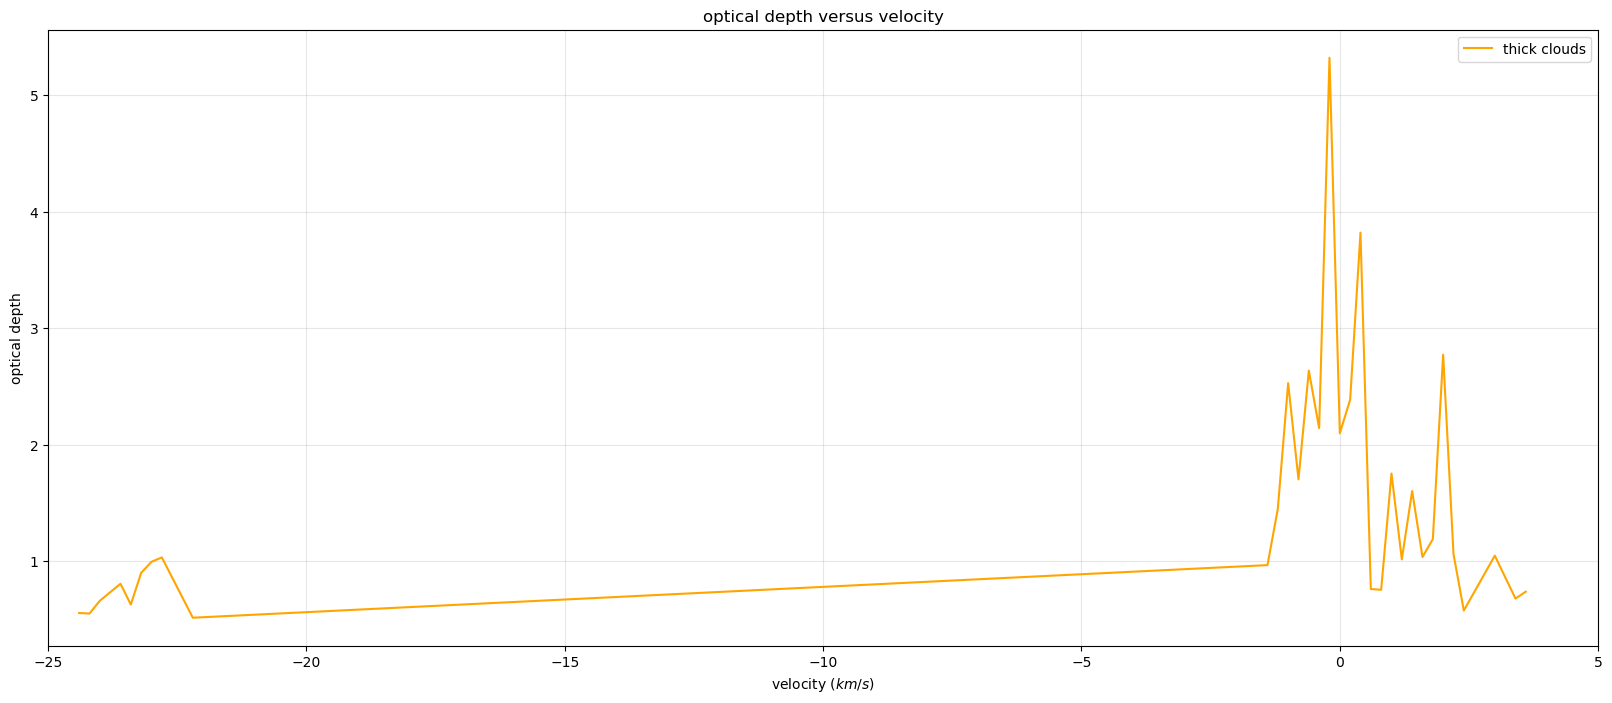

In [198]:
fat_coulds=gas_cloud[gas_cloud['optical depth']>0.5]
plt.figure(figsize=(20,8))
plt.plot(fat_coulds['velocity'],fat_coulds['optical depth'],color='orange',label='thick clouds')
plt.title('optical depth versus velocity')
plt.xlabel('velocity ($km/s$)')
plt.ylabel('optical depth')
plt.grid(True,alpha=0.3)
plt.xlim(-25,5)
plt.legend()
plt.show()

Yes, it is a system of thick clouds. 

### Part E: HI absorption features

(h) Now, propose an adequate model for the **optical-depth spectrum** to characterise the HI absorption features. Clearly state the number of free parameters and the motivation for choosing your model. 

model for two peacks is the Gaussian model for each peak. For each peak, you would need to apply this equation and add them together for the final result. 


$$
 \sum_{i=1}^{N} \tau_{0,i} \exp \left( -\frac{(v - v_i)^2}{2\sigma_i^2} \right)
$$

where:
* **$\tau_{0,i}$**: is the **Peak Optical Depth** (the maximum height) of the $i$-th component.
* **$v$**: is the **Velocity variable**, which corresponds to the X-axis of your graph.
* **$v_i$**: is the **Central Velocity** of the $i$-th component (the location of the peak on the velocity axis).
* **$\sigma_i$**: is the **Velocity Dispersion** (or Doppler width) of the $i$-th component, which determines the width of the Gaussian curve.

In [204]:
def gauss(v,sigma1,sigma2,sigma3,sigma4):
    ga1=points_max[0,1]*np.exp(-((v-points_max[0,0])**2)/(2*(sigma1**2)))
    ga2=points_max[1,1]*np.exp(-((v-points_max[1,0])**2)/(2*(sigma2**2)))
    ga3=points_max[2,1]*np.exp(-((v-points_max[2,0])**2)/(2*(sigma3**2)))
    ga4=points_max[3,1]*np.exp(-((v-points_max[3,0])**2)/(2*(sigma4**2)))
    return ga1+ga2+ga3+ga4


(i) Carry out the regression using your model in (f) and report the results including uncertainties. **Hint:** Providing initial guesses may aid the regression functions.



In [216]:
variables2,errors=opt.curve_fit(gauss,gas_cloud['velocity'],gas_cloud['optical depth'])
fit2_gas=gauss(gas_cloud['velocity'],*variables2)
errors2=np.sqrt(np.diag(errors))
for i in range(len(variables2)):
    print(f'for the sigma_{i+1} = {variables2[i]:.3f} +/- {errors2[i]:.3e}')

for the sigma_1 = 0.892 +/- 6.801e-02
for the sigma_2 = 0.219 +/- 7.121e-03
for the sigma_3 = 0.124 +/- 6.754e-03
for the sigma_4 = -0.200 +/- 1.192e-02


(j) Make a plot of the results. Show the **optical-depth spectrum** plus fitted model. Briefly describe the kinematics of the gas clouds.

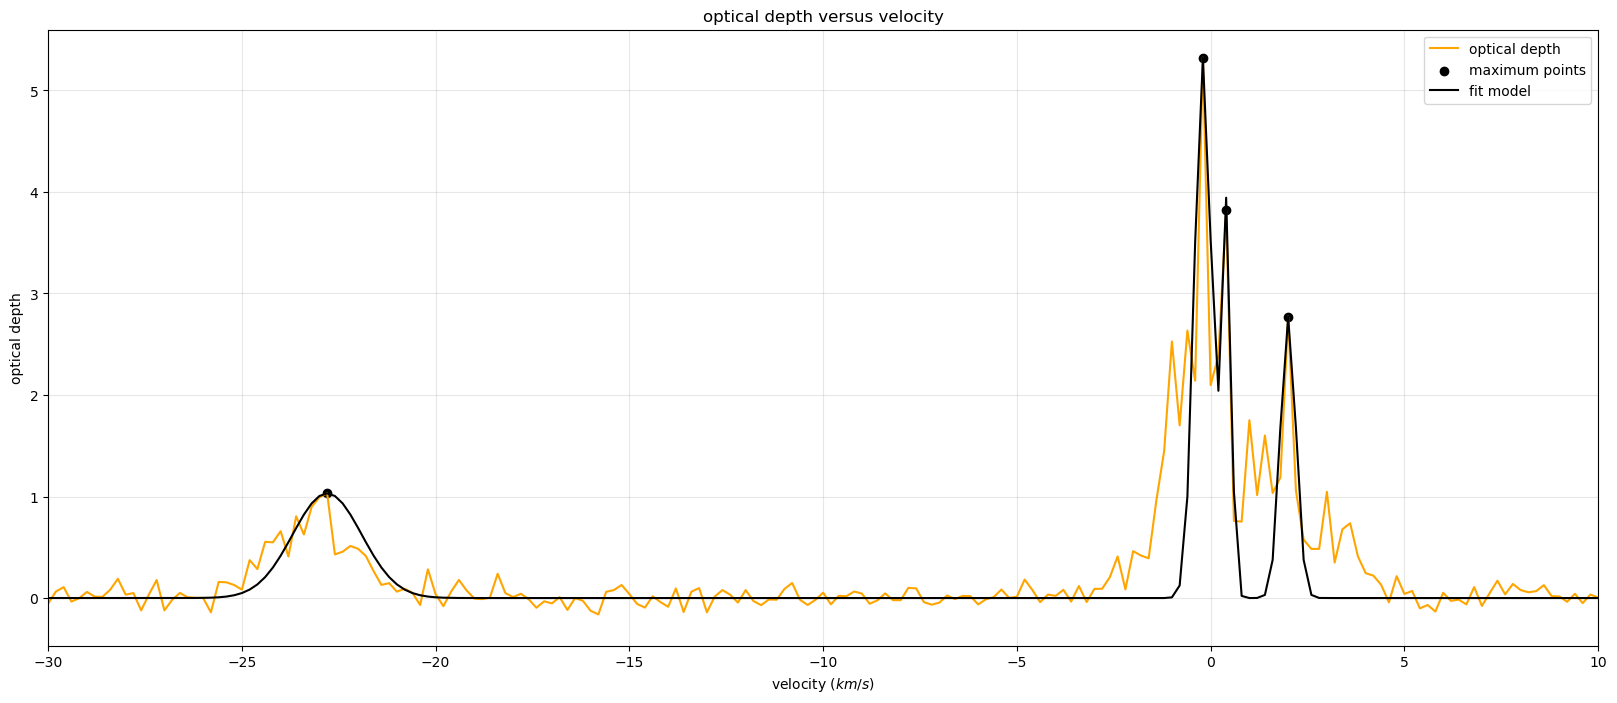

In [210]:
plt.figure(figsize=(20,8))
plt.plot(velocity,tao,color='orange',label='optical depth')
plt.scatter(points_max[:,0],points_max[:,1],color='black',label='maximum points')
plt.plot(gas_cloud['velocity'],fit2_gas,color='black',label='fit model')
plt.title('optical depth versus velocity')
plt.xlabel('velocity ($km/s$)')
plt.ylabel('optical depth')
plt.grid(True,alpha=0.3)
plt.xlim(-30,10)
plt.legend()
plt.show()

As can be seen, only the largest peaks, previously fixed, can behave like Gaussian distributions, and in the opposite case, it tends to become linear when it moves away from this range.
The designed model consists of a total of four parameters, where each parameter is related to each area of each Gaussian bell curve and depends on speed. Therefore, we have a system focused on graphing each main point.
* note:To make a more accurate curve, you need the local maximum peaks of everything in their respective coordinates (x, y) to be able to use this approximation. 